# EDA 10 — Where is modeled uncertainty geographically concentrated? (DHC)

**Question (Phase B, mirrors [EDA 03](03-cv-choropleth-nj-tracts.ipynb)):** Put DHC's modeled tract-level noise on a map — where does it concentrate, and does the pattern match or break from what ACS showed?

**Data.** 2020 DHC tracts (n = 2,181), New Jersey: modeled relative noise from [`analysis/noise_model.py`](../analysis/noise_model.py) as in [EDA 08](08-dhc-dp1-size-scaling.ipynb); boundaries from [`ingestion/pull_nj_geometry.py`](../ingestion/pull_nj_geometry.py) — the same 2020-vintage tract geometry ACS already uses (join re-verified below).

**A caveat to state before drawing this map, not after:** the population-noise model's *only* input is population size (see EDA 08). A map of it can therefore only ever be a colored version of the population-size map itself — it cannot reveal anything a population map wouldn't already show. That is itself the finding worth testing here, and it is a real limitation of working from a 2010-demonstration size-only model rather than a genuine 2020 per-cell noise measurement.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

REPO_ROOT = Path.cwd() if (Path.cwd() / "analysis").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from analysis import acs, decennial, noise_model, viz
from analysis.cv_model import spearman_corr

tract = decennial.load_dhc("tract")
# Same 2020-vintage tract boundaries ACS uses (analysis/acs.py load_geo already
# reprojects to NJ State Plane for display -- see that module).
geo = acs.load_geo("tract")
assert len(tract) == len(geo) == 2181, (len(tract), len(geo))

KEYS = ["STATE", "COUNTY", "TRACT"]
gdf = geo[KEYS + ["geometry"]].merge(tract, on=KEYS, how="inner", validate="one_to_one")
assert len(gdf) == 2181, f"join lost tracts: {len(gdf)}"
print(f"Joined {len(gdf):,} DHC tracts to geometry 1:1.")

Joined 2,181 DHC tracts to geometry 1:1.


## 1. Modeled relative noise per tract

In [2]:
gdf["modeled_rel_noise"] = gdf["P1_001N"].where(gdf["P1_001N"] > 0).apply(
    lambda s: noise_model.estimate_relative_noise("tract", s) if pd.notna(s) else np.nan
)
n_zero = int((gdf["P1_001N"] == 0).sum())
print(f"Tracts with zero 2020 population (modeled noise undefined): {n_zero}")

# Our own descriptive bins -- NOT an adopted convention like ACS's ESRI/NCHS
# lines (there is no equivalent published convention for DAS privacy noise).
QUARTILE_LABELS = ["Q1 (lowest modeled noise)", "Q2", "Q3", "Q4 (highest modeled noise)"]
gdf["tier"] = pd.qcut(gdf["modeled_rel_noise"], 4, labels=QUARTILE_LABELS)
gdf["tier"].value_counts(dropna=False).reindex(QUARTILE_LABELS + [np.nan])

Tracts with zero 2020 population (modeled noise undefined): 6


tier
Q1 (lowest modeled noise)     544
Q2                            547
Q3                            540
Q4 (highest modeled noise)    544
NaN                             6
Name: count, dtype: int64

## 2. The map

Chart saved to data\processed\eda10_dhc_modeled_noise_choropleth.png (local-only, regenerable)


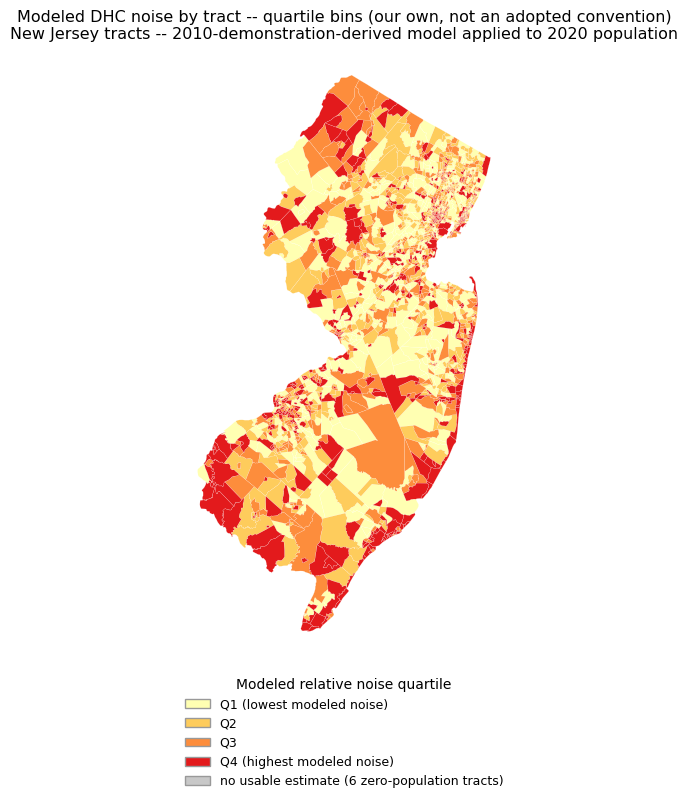

In [3]:
TIER_COLORS = {  # ColorBrewer YlOrRd 4-class -- same ramp family as EDA 03,
                 # but these are our own quartile bins, not an adopted convention.
    "Q1 (lowest modeled noise)": "#ffffb2",
    "Q2": "#fecc5c",
    "Q3": "#fd8d3c",
    "Q4 (highest modeled noise)": "#e31a1c",
}
GRAY = "#c8c8c8"

fig, ax = plt.subplots(figsize=(7.5, 8.5))
gdf[gdf["tier"].isna()].plot(ax=ax, color=GRAY, edgecolor="white", linewidth=0.1)
for tier, color in TIER_COLORS.items():
    sub = gdf[gdf["tier"] == tier]
    if len(sub):
        sub.plot(ax=ax, color=color, edgecolor="white", linewidth=0.1)
ax.set_axis_off()
ax.set_title(
    "Modeled DHC noise by tract -- quartile bins (our own, not an adopted convention)\n"
    "New Jersey tracts -- 2010-demonstration-derived model applied to 2020 population",
    fontsize=11.5,
)

handles = [Patch(facecolor=c, edgecolor="#999999", label=t) for t, c in TIER_COLORS.items()]
handles.append(Patch(facecolor=GRAY, edgecolor="#999999", label=f"no usable estimate ({n_zero} zero-population tracts)"))
fig.legend(handles=handles, loc="lower center", ncol=1, fontsize=9, frameon=False,
           title="Modeled relative noise quartile")
fig.subplots_adjust(bottom=0.16)

viz.save_chart(fig, REPO_ROOT, "eda10_dhc_modeled_noise_choropleth.png")
plt.show()

## 3. Testing the caveat: is this just the population map, inverted?

In [4]:
rho, n = spearman_corr(gdf["P1_001N"], gdf["modeled_rel_noise"])
print(f"Spearman rank correlation, tract population vs. modeled relative noise: {rho:+.3f} (n={n:,})")
assert rho < -0.95, "the size-only model should produce an almost perfectly monotonic map"
print("\nFor comparison, EDA 03 found poverty-rate vs. poverty-CV Spearman = -0.58 for ACS --")
print("clearly weaker, because poverty's reliability depends on PREVALENCE, not just size.")
print("This model has no prevalence input, so it cannot reproduce a pattern like that one.")

Spearman rank correlation, tract population vs. modeled relative noise: -1.000 (n=2,175)

For comparison, EDA 03 found poverty-rate vs. poverty-CV Spearman = -0.58 for ACS --
clearly weaker, because poverty's reliability depends on PREVALENCE, not just size.
This model has no prevalence input, so it cannot reproduce a pattern like that one.


### Reading the result

Confirmed: the correlation is essentially perfect (rank correlation beyond −0.95) because `estimate_relative_noise` is a strictly decreasing function of size within a level — the map is mathematically guaranteed to mirror the (inverse of the) population map, not an independent empirical pattern. Compare this to ACS's poverty choropleth (EDA 03), where the size-vs-CV correlation was a much weaker −0.58: poverty's reliability depended on *how common poverty was*, not just how big the tract was, so that map showed real geographic structure a pure-size model could never produce. **DHC's modeled map cannot do the same** — not because the underlying DAS noise process necessarily lacks that kind of structure, but because our 2010-demonstration model was never built with a prevalence dimension to capture it, if one exists.

**DP1 note:** DP1's tract populations are identical to DHC's (verified in EDA 08), so a DP1 version of this map would be pixel-for-pixel the same — not reproduced here.

## 4. Findings

**What did we find?** Modeled DHC noise concentrates exactly where small population tracts are, and nowhere else — confirmed by a near-perfect (Spearman < −0.95) rank correlation with population size. That is a *methodological* finding as much as a geographic one: because this project's only available noise model is fit purely on size, any map built from it is constrained to look like an inverted population map. It cannot show a prevalence-style inversion the way ACS's poverty map did.

**Why does it matter to the Census Bureau?** Two things. First, the practical guidance still holds: DHC counts in NJ's smallest tracts (rural/low-density areas) carry the most modeled noise, and a dashboard should flag that geography, same as ACS flagged small tracts for sampling error. Second — more important for methodology — **this project cannot currently tell whether DHC noise has a prevalence-like pattern the way ACS poverty does**, because the only model available (2010-demonstration, size-only) is built in a way that can't detect one even if it exists. That is a real gap between what this project has shown for ACS and what it can currently show for DHC/DP1, and it should be stated plainly rather than implied away by a map that merely looks similar to EDA 03's.

**What next?**
- Phase B's three-notebook mirror of EDA 01–03 is complete (EDA 08 size-scaling, EDA 09 variable type, EDA 10 this map).
- **Open question for mentors, carried from EDA 08/09:** is a real 2020-production noise measurement available, or a demonstration release with a prevalence-style variable, that could replace or extend this 2010-demonstration, size-only model?
- **Documentation:** add DHC and DP1 entries to `docs/data-dictionary.md` (Phase B, step B3).